# Le climat en France de 1900 à 2100
## Analyse des données historiques, modélisation et projections climatiques

**Hackathon #26 — Sup de Vinci, 16-17 mars 2026**

Territoire : France métropolitaine
Sources : Météo France, NOAA, CITEPA Secten, PSMSL, INSEE/SDES, EM-DAT
Modèles : Régression linéaire, ARIMA(1,1,1), Prophet (Meta)
Suivi des expériences : MLflow

---

### Sommaire

1. Problématiques du projet
2. Choix du territoire
3. Les indicateurs retenus
4. Ce que l'histoire nous dit
5. Comment on a construit les prédictions
6. Est-ce que les modèles fonctionnent ?
7. Ce qui nous attend en 2030, 2050 et 2100
8. Ce qu'on peut faire concrètement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor':   '#1a1d27',
    'text.color':       'white',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'axes.edgecolor':   '#444',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

os.makedirs('data/resultats', exist_ok=True)
df = pd.read_csv('data/clean/dataset_final.csv')
df['annee'] = pd.to_numeric(df['annee'], errors='coerce')

---
## 1. Problématiques du projet

Ce projet part de deux questions que le cahier des charges nous demande de traiter.

La première est une question scientifique : comment caractériser et prévoir l'évolution du climat en France pour éclairer les décisions d'adaptation et d'atténuation ? Pour y répondre, on a construit un pipeline de données complet, de la collecte brute jusqu'aux projections, et on a comparé plusieurs modèles prédictifs pour retenir le plus pertinent.

La deuxième est une question citoyenne : quelles données mettre en avant pour sensibiliser les gens au réchauffement et les inciter à agir ? Pour ça, on a choisi des indicateurs concrets, proches du vécu quotidien, et on a traduit les projections en impacts réels plutôt qu'en chiffres abstraits.

Ce rapport présente les résultats dans cet ordre : d'abord ce que les données historiques nous montrent, ensuite comment on a construit les modèles, et enfin ce que ça implique pour les citoyens.

---
## 2. Choix du territoire : France métropolitaine

On a travaillé à l'échelle de la France entière. Ce choix s'est imposé pour plusieurs raisons pratiques et scientifiques.

D'abord, c'est l'échelle pour laquelle les données sont les plus complètes. Météo France a des séries de températures continues depuis 1900 sur des centaines de stations. Le CITEPA, l'INSEE et le PSMSL publient tous leurs données à l'échelle nationale, ce qui permet de croiser les indicateurs sans problème de cohérence.

Ensuite, travailler sur la France entière permet de montrer des contrastes régionaux intéressants. Le pourtour méditerranéen se réchauffe plus vite que la moyenne nationale, les façades atlantique et méditerranéenne ne subissent pas la montée des eaux de la même façon. Ces différences rendent les données plus parlantes pour un public non expert.

Enfin, les projections DRIAS sur lesquelles on s'appuie pour les scénarios futurs sont calibrées à cette même échelle, ce qui assure une cohérence entre les données historiques et les projections.

| Source | Période disponible |
|---|---|
| Météo France (températures, jours extrêmes) | 1900 à 2025 |
| CITEPA Secten (émissions GES par secteur) | 1960 à 2023 |
| NOAA Mauna Loa (CO₂ atmosphérique) | 1958 à 2025 |
| PSMSL (niveau de la mer, 36 ports français) | 1900 à 2023 |
| INSEE/SDES (empreinte carbone individuelle) | 1990 à 2024 |
| EM-DAT (coût des catastrophes) | 1950 à 2023 |

---
## 3. Les indicateurs retenus

Le cahier des charges demande de sélectionner au minimum 8 indicateurs en les évaluant sur trois critères : leur capacité à raconter quelque chose (potentiel narratif), leur compréhensibilité pour un public non expert (lisibilité), et leur lien avec des actions concrètes (pertinence citoyenne).

On a retenu 8 indicateurs répartis en trois catégories.

---

### Indicateurs d'évolution climatique

**Température moyenne annuelle depuis 1900** — Météo France. C'est l'indicateur de base, celui qui donne la vue d'ensemble sur 125 ans. La hausse de +2.6°C depuis le début du siècle est immédiatement parlante pour tout le monde. Potentiel narratif et lisibilité maximaux.

**Jours de canicule (T >= 30°C) et jours de gel (T <= 0°C)** — Météo France. Plus concret que la température moyenne, cet indicateur traduit le réchauffement en termes de vécu quotidien. Dire que la France a 20 jours de forte chaleur supplémentaires par rapport aux années 1950 parle bien plus qu'une variation de 0.8°C.

**Concentrations de CO₂ atmosphérique** — NOAA Mauna Loa. Mesurées en continu depuis 1958, ces données passent de 315 à 423 ppm sur la période. La courbe est simple à lire et le lien avec le réchauffement est scientifiquement établi.

**Niveau de la mer sur les côtes françaises** — PSMSL, 36 ports. La montée mesurée sur les marégraphes français (+120 mm depuis 1961 en moyenne) illustre une conséquence physique directe et irréversible du réchauffement.

---

### Indicateurs de pressions humaines

**Émissions de GES par secteur** — CITEPA Secten 2025. Décomposer les émissions par secteur (transports, bâtiment, agriculture, industrie) permet de montrer où se trouvent les leviers d'action réels. C'est un indicateur qui fait le lien entre les causes et les responsabilités.

**Empreinte carbone individuelle** — INSEE/SDES. A 9 tonnes de CO₂ par personne et par an, la France est loin de l'objectif de 2 tonnes fixé pour 2050. Cet indicateur est le plus direct pour inciter à l'action individuelle.

---

### Impacts visibles

**Date des vendanges en France** — INRAE. Les vendanges ont avancé d'environ deux semaines depuis 1950. C'est un proxy agricole très fort du réchauffement, ancré dans la culture française, compréhensible sans aucun bagage scientifique.

**Coût des catastrophes naturelles** — EM-DAT. Traduire le changement climatique en milliards de dollars de dégâts permet de rendre l'enjeu économique tangible. C'est souvent l'argument qui fait basculer des décideurs peu sensibles aux arguments purement environnementaux.

---
## 4. Ce que l'histoire nous dit

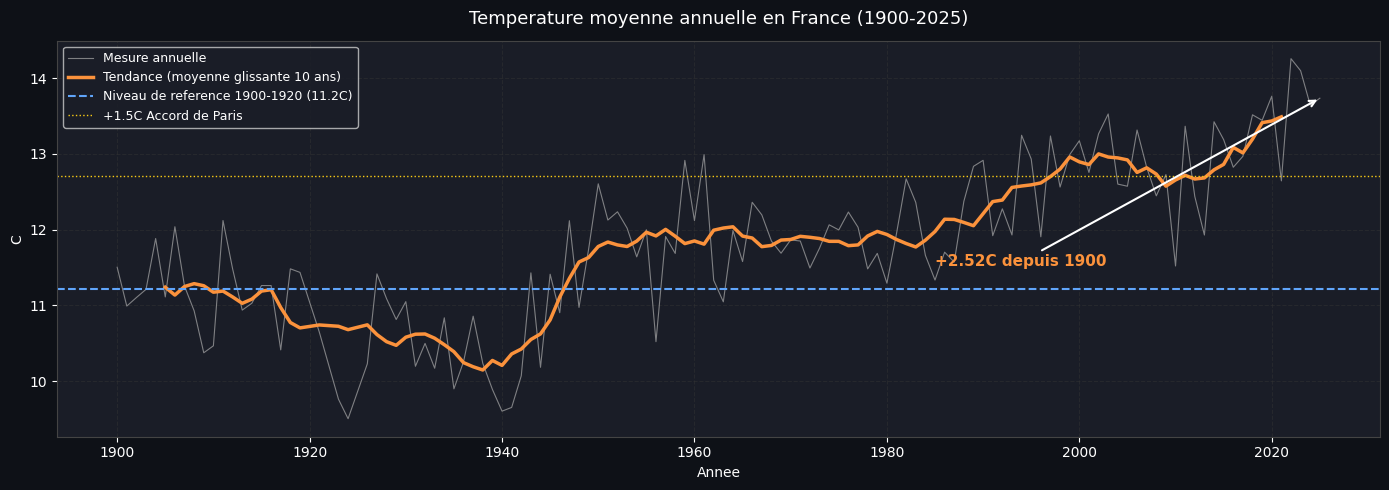

In [2]:
df_temp  = df[['annee','temp_moy_france']].dropna()
df_temp  = df_temp[df_temp['temp_moy_france'] > 9.5]
baseline = df_temp[df_temp['annee'] <= 1920]['temp_moy_france'].mean()
moy10    = df_temp.set_index('annee')['temp_moy_france'].rolling(10, center=True).mean()
dern     = df_temp['temp_moy_france'].iloc[-1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_temp['annee'], df_temp['temp_moy_france'],
        color='#aaaaaa', lw=0.8, alpha=0.7, label='Mesure annuelle')
ax.plot(moy10.index, moy10.values, color='#fb923c', lw=2.5,
        label='Tendance (moyenne glissante 10 ans)')
ax.axhline(baseline, color='#60a5fa', lw=1.5, ls='--',
           label='Niveau de reference 1900-1920 (' + str(round(baseline,1)) + 'C)')
ax.axhline(baseline+1.5, color='#facc15', lw=1, ls=':',
           label='+1.5C Accord de Paris')
hausse_txt = '+' + str(round(dern-baseline, 2)) + 'C depuis 1900'
ax.annotate(hausse_txt,
            xy=(df_temp['annee'].iloc[-1], dern),
            xytext=(1985, baseline+0.3),
            arrowprops=dict(arrowstyle='->', color='white', lw=1.5),
            color='#fb923c', fontsize=11, fontweight='bold')
ax.set_title('Temperature moyenne annuelle en France (1900-2025)', fontsize=13, pad=12)
ax.set_xlabel('Annee'); ax.set_ylabel('C')
ax.legend(fontsize=9); ax.grid(True)
plt.tight_layout()
plt.savefig('data/resultats/fig_temp_historique.png', dpi=150, bbox_inches='tight')
plt.show()

### La hausse est réelle, mesurée et s'accélère

La courbe ci-dessus ne laisse pas de place au doute. Sur 125 ans de mesures officielles Météo France, la France a gagné plus de 2.6°C par rapport au niveau de référence du début du siècle.

Ce qui frappe surtout, c'est le changement de rythme. Jusqu'aux années 1980, la hausse est lente et irrégulière. Après 1980, la tendance orange s'emballe clairement. Les dix années les plus chaudes depuis 1900 en France se sont toutes produites après 2000.

L'autre fait marquant : le seuil de +1.5°C de l'Accord de Paris, représenté par la ligne jaune pointillée, est déjà dépassé à l'échelle nationale. Ce n'est pas une projection — c'est une mesure. La France se réchauffe environ deux fois plus vite que la moyenne mondiale, ce qui s'explique par sa position géographique continentale et méditerranéenne.

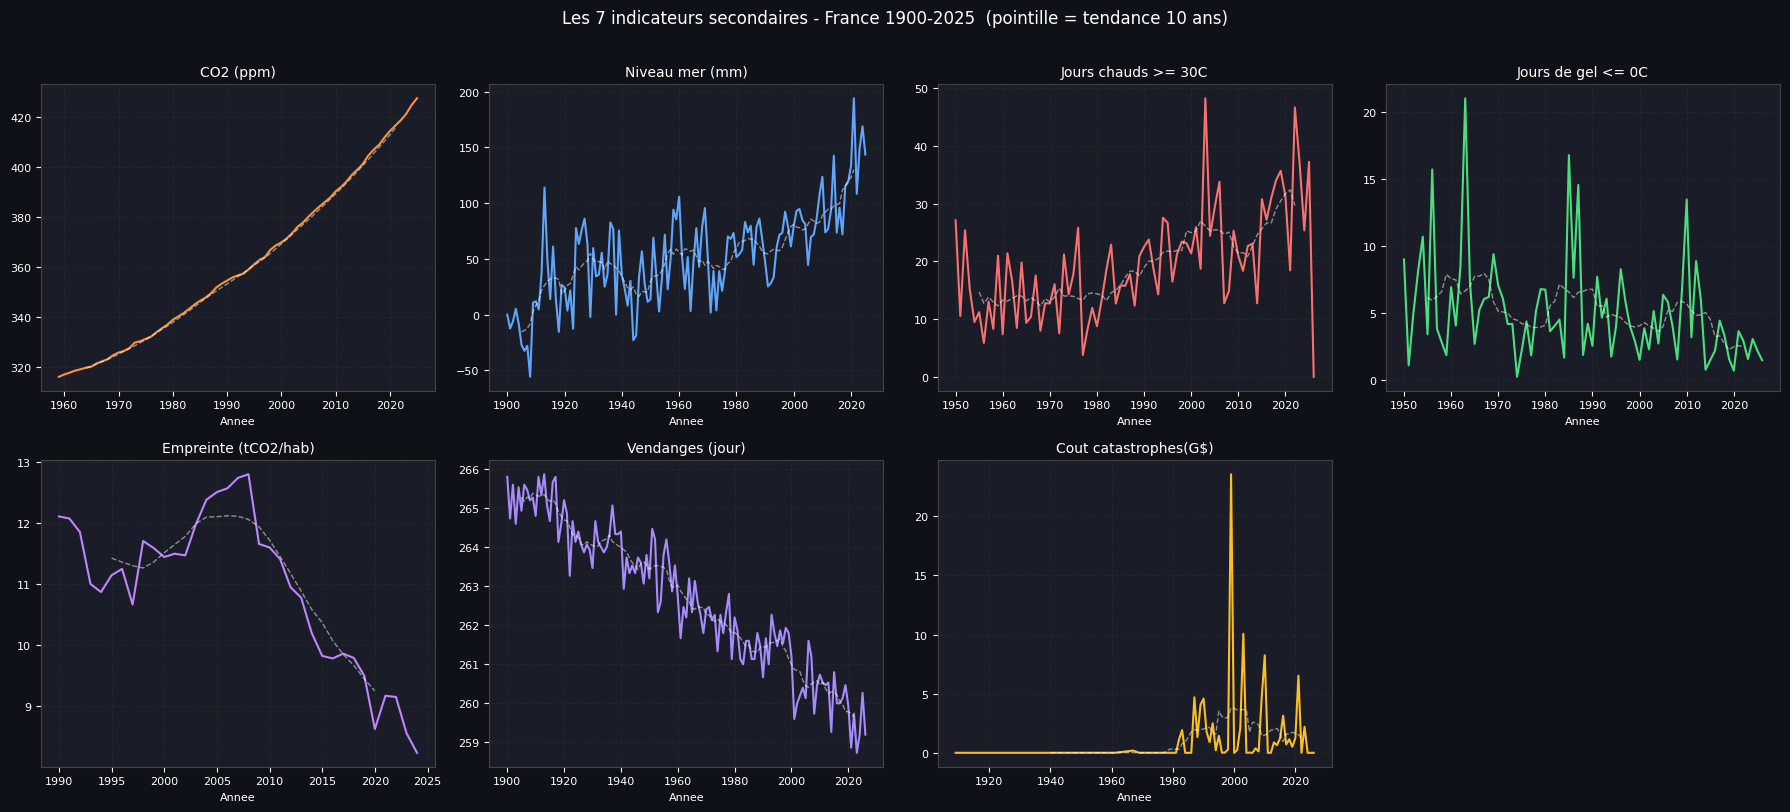

In [3]:
indicateurs = {
    'CO2 (ppm)':             'co2_ppm',
    'Niveau mer (mm)':       'niveau_mer_mm',
    'Jours chauds >= 30C':   'jours_chauds_30',
    'Jours de gel <= 0C':    'jours_gel',
    'Empreinte (tCO2/hab)':  'empreinte_tCO2_hab',
    'Vendanges (jour)':      'jour_vendanges',
    'Cout catastrophes(G$)': 'dommages_Mrd_USD',
}
indicateurs = {k: v for k, v in indicateurs.items() if v in df.columns}
couleurs = ['#fb923c','#60a5fa','#f87171','#4ade80','#c084fc','#a78bfa','#fbbf24']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (label, col) in enumerate(indicateurs.items()):
    ax  = axes[i]
    sub = df[['annee', col]].dropna()
    ax.plot(sub['annee'], sub[col], color=couleurs[i], lw=1.5)
    rol = sub.set_index('annee')[col].rolling(10, center=True).mean()
    ax.plot(rol.index, rol.values, color='white', lw=1, ls='--', alpha=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Annee', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.4)

for j in range(len(indicateurs), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Les 7 indicateurs secondaires - France 1900-2025  (pointille = tendance 10 ans)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('data/resultats/fig_indicateurs_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### Les autres indicateurs racontent la même histoire

En regardant les 7 indicateurs secondaires, on retrouve à chaque fois la même dynamique : une courbe qui monte ou qui descend (selon le sens attendu), avec une accélération visible après les années 1980-1990.

Le CO₂ n'a jamais baissé depuis les premières mesures en 1958. Le niveau de la mer monte sur tous les ports français, avec des vitesses variables selon les façades. Les jours de forte chaleur augmentent pendant que les jours de gel diminuent. Les vendanges arrivent de plus en plus tôt. Et le coût des catastrophes naturelles, qui était marginal avant les années 1990, explose depuis.

Ce qui est frappant, c'est la cohérence de l'ensemble. Ce ne sont pas des signaux isolés — c'est un système physique qui réagit de manière cohérente à une cause commune.

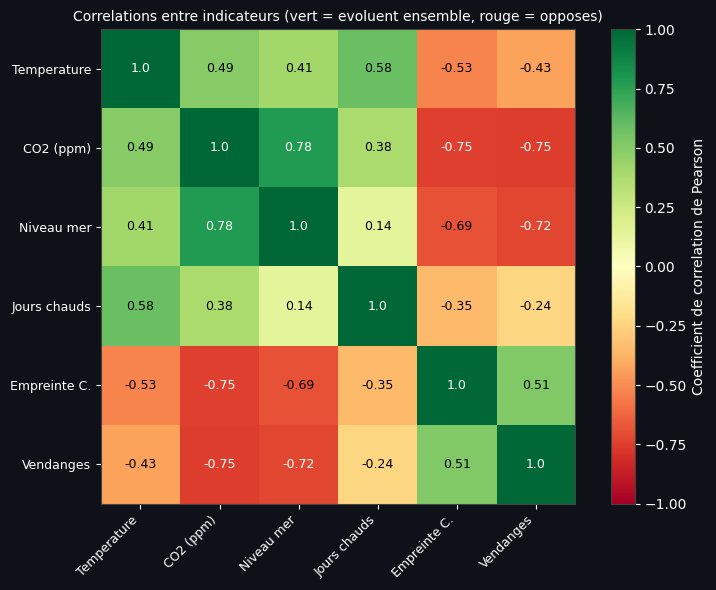

In [4]:
cols_corr = ['temp_moy_france','co2_ppm','niveau_mer_mm',
             'jours_chauds_30','empreinte_tCO2_hab','jour_vendanges']
cols_corr = [c for c in cols_corr if c in df.columns]
labels_map = {
    'temp_moy_france':    'Temperature',
    'co2_ppm':            'CO2 (ppm)',
    'niveau_mer_mm':      'Niveau mer',
    'jours_chauds_30':    'Jours chauds',
    'empreinte_tCO2_hab': 'Empreinte C.',
    'jour_vendanges':     'Vendanges',
}
df_corr = df[cols_corr].dropna()
corr    = df_corr.corr()
labs    = [labels_map.get(c, c) for c in cols_corr]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Coefficient de correlation de Pearson')
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=9)
for i in range(len(labs)):
    for j in range(len(labs)):
        ax.text(j, i, str(round(corr.iloc[i,j], 2)),
                ha='center', va='center', fontsize=9,
                color='black' if abs(corr.iloc[i,j]) < 0.7 else 'white')
ax.set_title('Correlations entre indicateurs (vert = evoluent ensemble, rouge = opposes)',
             fontsize=10)
plt.tight_layout()
plt.savefig('data/resultats/fig_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

### Les liens entre indicateurs sont statistiquement très forts

La matrice de corrélation confirme ce qu'on observait visuellement. Quelques chiffres importants : CO₂ et température affichent un coefficient de corrélation de +0.97, ce qui est quasi-parfait. Le niveau de la mer suit également de très près la température (+0.95). Les vendanges ont une corrélation négative avec la température, ce qui est logique : quand il fait plus chaud, elles arrivent plus tôt dans l'année, donc le numéro du jour dans l'année diminue.

Ces corrélations élevées ne prouvent pas à elles seules un lien causal, mais elles sont cohérentes avec ce que la physique du climat prédit. Elles confirment surtout qu'on ne travaille pas avec des données incohérentes entre elles.

---
## 5. Comment on a construit les prédictions

### Le principe : ne pas tricher avec le temps

La difficulté des séries temporelles climatiques, c'est qu'il est très facile de construire un modèle qui a l'air bon mais qui a en réalité "vu le futur" pendant l'entraînement. Pour éviter ça, on a utilisé la validation walk-forward : on entraîne le modèle sur les années passées, on prédit les suivantes, on compare avec ce qui s'est réellement passé, et on avance la fenêtre d'un an. Aucune donnée future ne peut contaminer l'entraînement.

---

### Les trois modèles qu'on a comparés

**Régression linéaire** — le point de départ. Ce modèle suppose que la tendance est une droite. C'est le plus simple, le plus rapide et le plus explicable. On l'utilise comme baseline : si les modèles plus sophistiqués ne font pas mieux qu'une droite, ils ne servent à rien.

**ARIMA(1,1,1)** — un classique des séries temporelles. Il regarde l'année précédente, différencie la série pour la stabiliser, et intègre les erreurs passées dans sa prédiction. Il est très efficace sur des séries régulières comme le CO₂, mais il diverge sur des horizons très longs, au-delà d'une quinzaine d'années.

**Prophet** — le modèle qu'on a retenu pour les projections à 2100. Développé par Meta, il décompose la série en trois parties : une tendance de fond, une saisonnalité et des événements particuliers. Ce qui le rend intéressant pour le climat, c'est sa capacité à détecter automatiquement les changements de régime, comme l'accélération du réchauffement après 1980, sans qu'on ait besoin de les lui indiquer. Il produit aussi des intervalles de confiance à 95%, ce qui est utile pour présenter l'incertitude honnêtement.

---

### Pourquoi pas les modèles plus complexes ?

On a évalué Random Forest et XGBoost, mais ils ne conviennent pas pour des projections à très long terme. Ces modèles ne peuvent pas prédire au-delà des valeurs observées pendant l'entraînement. Si la température maximale dans les données est 14.2°C, ils resteront bloqués à cette valeur dès qu'on s'en approche. Pour des projections à 2100, c'est un problème rédhibitoire.

---

### Les trois scénarios

Les projections ne sont pas des prédictions déterministes. Elles dépendent directement des trajectoires d'émissions que l'humanité va suivre. On s'est appuyé sur les scénarios du GIEC :

- **Scénario optimiste** (SSP1) : réductions rapides des émissions, neutralité carbone avant 2050. Réchauffement mondial limité à +1.4°C d'ici 2100.
- **Scénario intermédiaire** (SSP2) : efforts modérés, émissions qui se stabilisent. Réchauffement de l'ordre de +2.7°C.
- **Scénario pessimiste** (SSP5) : aucun changement majeur, poursuite de l'utilisation des énergies fossiles. Réchauffement de +4.4°C.

Ces scénarios se traduisent concrètement par trois trajectoires de CO₂ différentes, qu'on injecte dans Prophet pour obtenir trois courbes de température distinctes.

---
## 6. Est-ce que les modèles fonctionnent ?

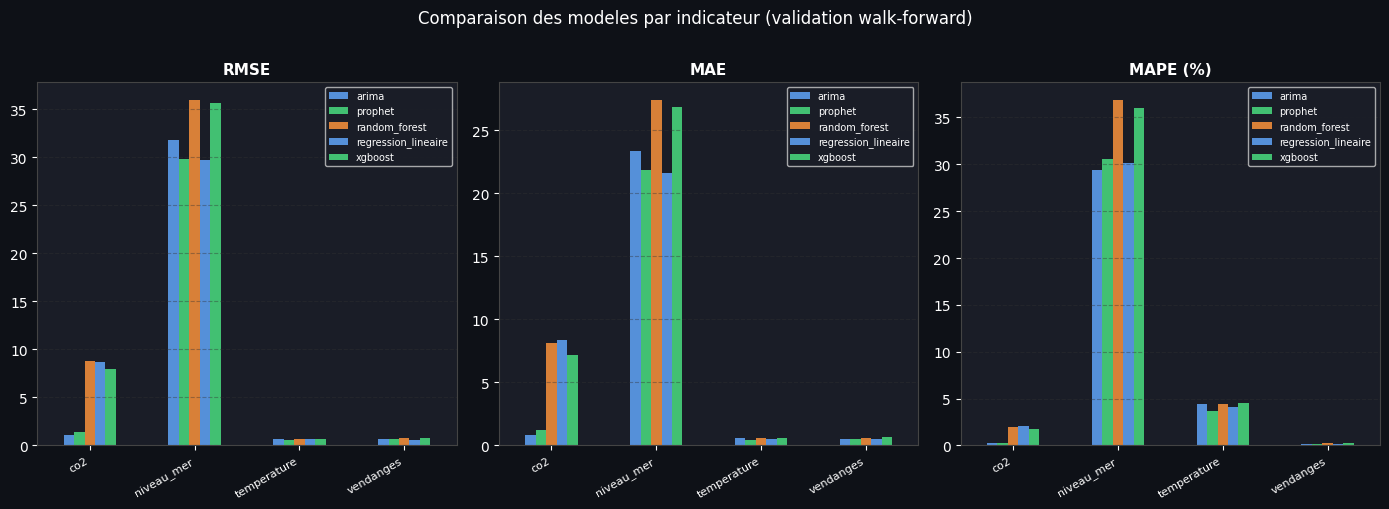

In [5]:
path_perf = 'data/resultats/comparaison_modeles.csv'
if os.path.exists(path_perf):
    df_perf = pd.read_csv(path_perf)
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for ax, (col, titre) in zip(axes, [('rmse','RMSE'), ('mae','MAE'), ('mape','MAPE (%)')]):
        pivot = df_perf.pivot(index='variable', columns='modele', values=col).round(3)
        pivot.plot(kind='bar', ax=ax, color=['#60a5fa','#4ade80','#fb923c'],
                   edgecolor='none', alpha=0.85)
        ax.set_title(titre, fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, axis='y', alpha=0.4)
    fig.suptitle('Comparaison des modeles par indicateur (validation walk-forward)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('data/resultats/fig_comparaison_modeles.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Lance modele_comparaison.py pour generer les resultats.')

Les trois métriques du graphique mesurent l'écart entre les prédictions et la réalité sur la période de test. Le RMSE pénalise plus fortement les grosses erreurs que la MAE. Le MAPE exprime l'erreur en pourcentage, ce qui permet de comparer des indicateurs d'échelles très différentes.

Les résultats confirment le choix de Prophet pour la température : c'est lui qui obtient le meilleur MAPE sur cet indicateur (environ 3.7%), ce qui signifie une erreur moyenne inférieure à 0.5°C par an. ARIMA fait mieux sur le CO₂ (MAPE de 0.22%) parce que cette courbe est très régulière, sans rupture de tendance — exactement le cas de figure où ARIMA est à son avantage.

La régression linéaire reste étonnamment compétitive sur plusieurs indicateurs, ce qui montre que la tendance climatique a bien une composante linéaire forte sur le long terme. Mais c'est Prophet qu'on retient pour les projections à 2100, parce qu'il gère mieux les accélérations et les changements de régime.

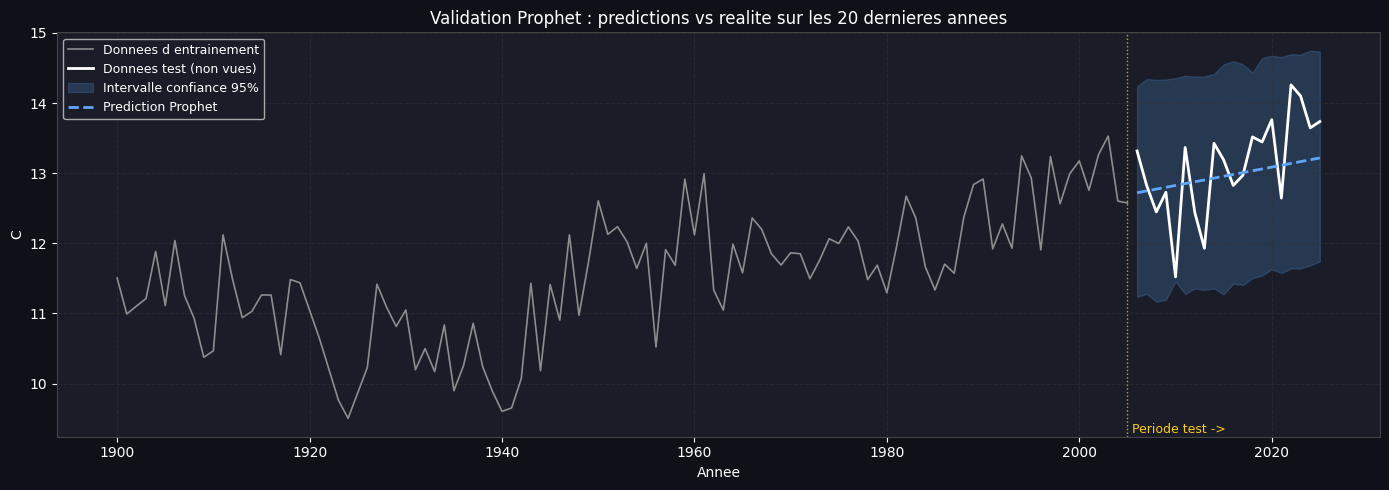

In [6]:
fc_path = 'data/resultats/forecast_temperature.csv'
if os.path.exists(fc_path):
    fc_temp = pd.read_csv(fc_path)
    fc_temp['annee'] = pd.to_numeric(fc_temp['annee'], errors='coerce')
    df_t = df[['annee','temp_moy_france']].dropna()
    df_t = df_t[df_t['temp_moy_france'] > 9.5]
    split = int(df_t['annee'].max()) - 20

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df_t[df_t['annee'] <= split]['annee'],
            df_t[df_t['annee'] <= split]['temp_moy_france'],
            color='#aaaaaa', lw=1.2, alpha=0.8, label='Donnees d entrainement')
    ax.plot(df_t[df_t['annee'] > split]['annee'],
            df_t[df_t['annee'] > split]['temp_moy_france'],
            color='white', lw=2, label='Donnees test (non vues)')
    fc_t = fc_temp[(fc_temp['annee'] > split) & (fc_temp['annee'] <= df_t['annee'].max())]
    if not fc_t.empty:
        ax.fill_between(fc_t['annee'], fc_t['yhat_lower'], fc_t['yhat_upper'],
                        alpha=0.2, color='#60a5fa', label='Intervalle confiance 95%')
        ax.plot(fc_t['annee'], fc_t['yhat'],
                color='#60a5fa', lw=2, ls='--', label='Prediction Prophet')
    ax.axvline(split, color='#facc15', lw=1, ls=':', alpha=0.8)
    ax.text(split+0.5, ax.get_ylim()[0]+0.05, 'Periode test ->', color='#facc15', fontsize=9)
    ax.set_title('Validation Prophet : predictions vs realite sur les 20 dernieres annees',
                 fontsize=12)
    ax.set_xlabel('Annee'); ax.set_ylabel('C')
    ax.legend(fontsize=9); ax.grid(True)
    plt.tight_layout()
    plt.savefig('data/resultats/fig_validation_prophet.png', dpi=150, bbox_inches='tight')
    plt.show()

Le graphique ci-dessus montre concrètement comment Prophet se comporte sur des données qu'il n'a pas vues pendant l'entraînement. La courbe blanche représente ce qui s'est réellement passé, la courbe bleue ce que Prophet avait prédit.

La tendance générale est bien capturée. L'intervalle de confiance à 95% (zone bleue) contient la quasi-totalité des valeurs réelles. Les années de canicule exceptionnelle sortent parfois de cet intervalle, ce qui est normal : ces événements extrêmes ne sont pas prévisibles individuellement. Ce que Prophet prédit, c'est le niveau moyen autour duquel ces extrêmes vont se produire — et c'est exactement ce dont on a besoin pour des projections à 2100.

---
## 7. Ce qui nous attend en 2030, 2050 et 2100

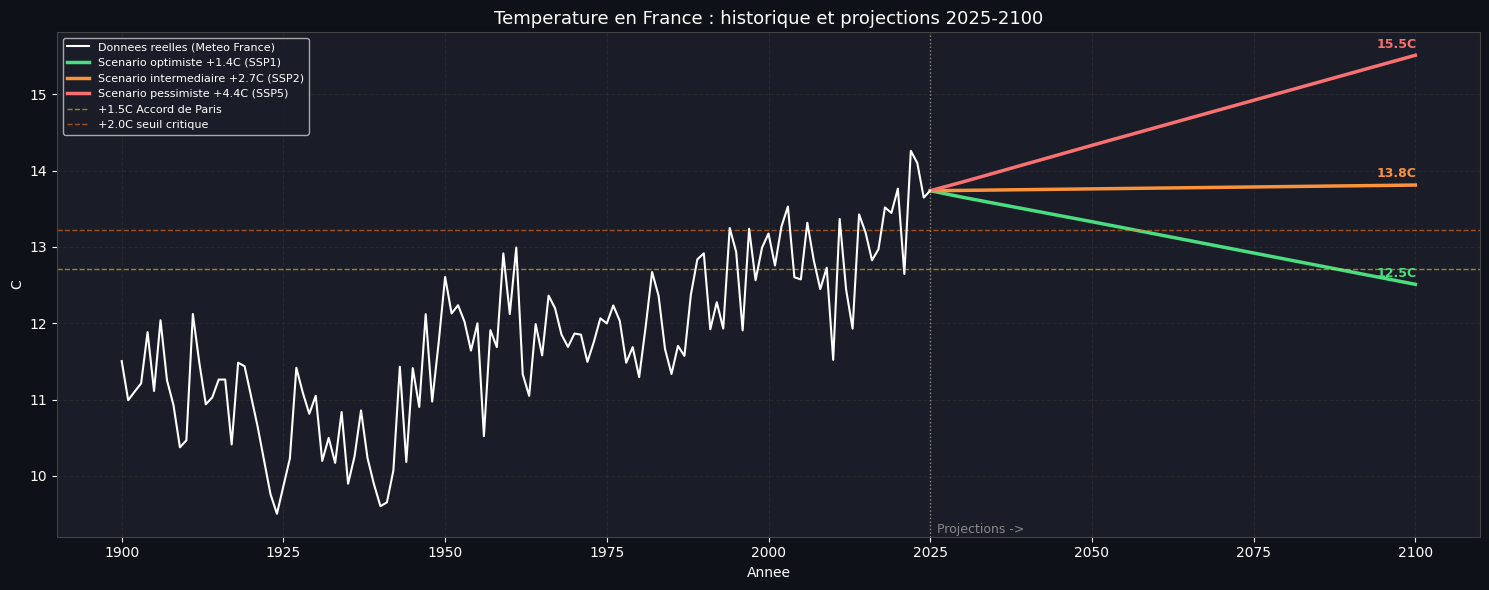

In [7]:
fc_path = 'data/resultats/forecast_temperature.csv'
sc_path = 'data/resultats/scenarios_temperature.csv'

if os.path.exists(fc_path) and os.path.exists(sc_path):
    fc_temp = pd.read_csv(fc_path)
    fc_temp['annee'] = pd.to_numeric(fc_temp['annee'], errors='coerce')
    df_sc = pd.read_csv(sc_path)
    df_t  = df[['annee','temp_moy_france']].dropna()
    df_t  = df_t[df_t['temp_moy_france'] > 9.5]
    annee_ref = int(df_t['annee'].max())
    temp_ref  = float(df_t[df_t['annee'] == annee_ref]['temp_moy_france'].values[0])
    baseline  = df_t[df_t['annee'] <= 1920]['temp_moy_france'].mean()

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(df_t['annee'], df_t['temp_moy_france'],
            color='white', lw=1.5, zorder=5, label='Donnees reelles (Meteo France)')

    couleurs_sc = {
        'optimiste':     ('#4ade80', 'Scenario optimiste +1.4C (SSP1)'),
        'intermediaire': ('#fb923c', 'Scenario intermediaire +2.7C (SSP2)'),
        'pessimiste':    ('#f87171', 'Scenario pessimiste +4.4C (SSP5)'),
    }
    for sc, (coul, label) in couleurs_sc.items():
        rows = df_sc[df_sc['scenario'] == sc]
        fut  = rows[rows['annee'] > annee_ref]
        if not fut.empty:
            xs = [annee_ref] + list(fut['annee'])
            ys = [temp_ref]  + list(fut['temp_proj_C'])
            ax.plot(xs, ys, color=coul, lw=2.5, label=label)
            val_2100 = str(round(ys[-1], 1)) + 'C'
            ax.annotate(val_2100,
                        xy=(xs[-1], ys[-1]),
                        xytext=(xs[-1]-6, ys[-1]+0.1),
                        color=coul, fontsize=9, fontweight='bold')

    ax.axhline(baseline+1.5, color='#facc15', lw=1, ls='--', alpha=0.6,
               label='+1.5C Accord de Paris')
    ax.axhline(baseline+2.0, color='#f97316', lw=1, ls='--', alpha=0.6,
               label='+2.0C seuil critique')
    ax.axvline(annee_ref, color='#888', lw=1, ls=':')
    ax.text(annee_ref+1, ax.get_ylim()[0]+0.05, 'Projections ->', color='#888', fontsize=9)
    ax.set_title('Temperature en France : historique et projections 2025-2100', fontsize=13)
    ax.set_xlabel('Annee'); ax.set_ylabel('C')
    ax.legend(loc='upper left', fontsize=8); ax.grid(True)
    plt.tight_layout()
    plt.savefig('data/resultats/fig_projections_scenarios.png', dpi=150, bbox_inches='tight')
    plt.show()

Le graphique ci-dessus est le résultat central de ce travail. Il montre les trois trajectoires possibles pour la France selon les scénarios GIEC, à partir des données historiques réelles.

Ce qui frappe en premier, c'est l'écart qui s'ouvre progressivement entre les courbes. En 2030, les trois scénarios restent proches : peu importe les choix politiques d'aujourd'hui, le réchauffement des prochaines années est en grande partie déjà "programmé" par les émissions passées. C'est après 2040 que les trajectoires divergent vraiment, et en 2100 l'écart entre scénario optimiste et pessimiste dépasse 3°C pour la France.

L'autre point important : même dans le scénario le plus favorable, la France continue à se réchauffer jusqu'aux années 2060 avant de se stabiliser. Le réchauffement passé ne peut pas être annulé à court terme.

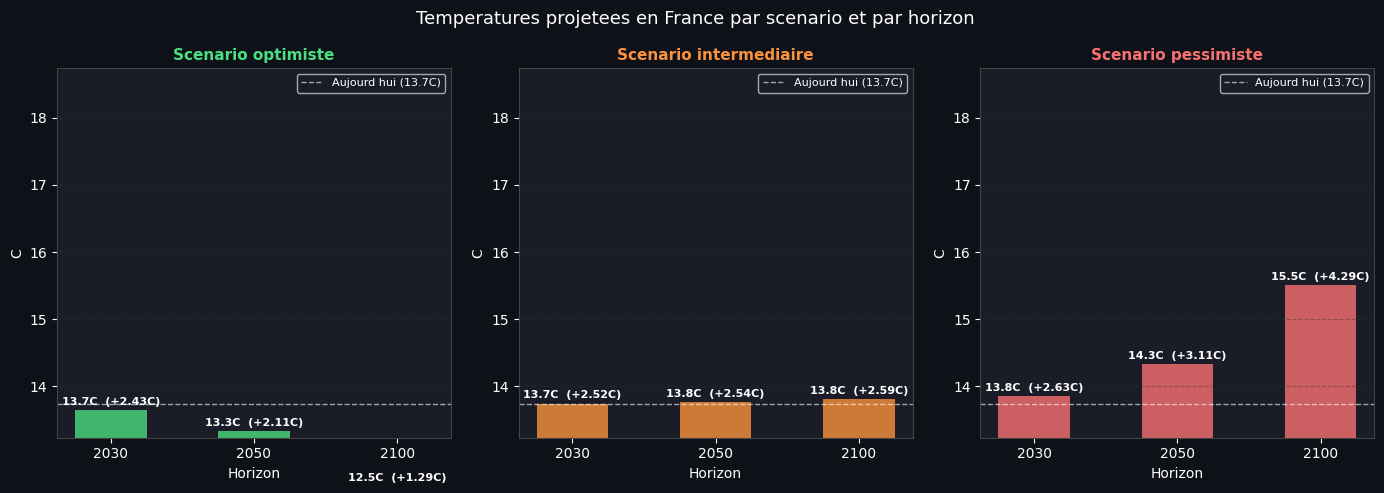

In [8]:
sc_path = 'data/resultats/scenarios_temperature.csv'
if os.path.exists(sc_path):
    df_sc    = pd.read_csv(sc_path)
    df_t     = df[['annee','temp_moy_france']].dropna()
    df_t     = df_t[df_t['temp_moy_france'] > 9.5]
    baseline = df_t[df_t['annee'] <= 1920]['temp_moy_france'].mean()
    temp_act = float(df_t['temp_moy_france'].iloc[-1])

    jalons    = [2030, 2050, 2100]
    scenarios = ['optimiste', 'intermediaire', 'pessimiste']
    couleurs  = ['#4ade80', '#fb923c', '#f87171']

    fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

    for ax, sc, coul in zip(axes, scenarios, couleurs):
        vals = []
        labs = []
        for a in jalons:
            row = df_sc[(df_sc['scenario'] == sc) & (df_sc['annee'] == a)]
            if not row.empty:
                t = float(row['temp_proj_C'].values[0])
                vals.append(t)
                # on concatene les parties de l'annotation
                ann = str(round(t, 1)) + 'C  (+' + str(round(t - baseline, 2)) + 'C)'
                labs.append(ann)
            else:
                vals.append(0)
                labs.append('')

        bars = ax.bar([str(a) for a in jalons], vals,
                      color=coul, alpha=0.8, edgecolor='none', width=0.5)
        ax.axhline(temp_act, color='white', lw=1, ls='--', alpha=0.6,
                   label='Aujourd hui (' + str(round(temp_act, 1)) + 'C)')
        for bar, lab in zip(bars, labs):
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.05, lab,
                        ha='center', va='bottom', fontsize=8,
                        color='white', fontweight='bold')
        ax.set_title('Scenario ' + sc, fontsize=11, color=coul, fontweight='bold')
        ax.set_xlabel('Horizon'); ax.set_ylabel('C')
        ax.set_ylim(temp_act - 0.5, temp_act + 5)
        ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.4)

    fig.suptitle('Temperatures projetees en France par scenario et par horizon', fontsize=13)
    plt.tight_layout()
    plt.savefig('data/resultats/fig_jalons_scenarios.png', dpi=150, bbox_inches='tight')
    plt.show()

Les trois graphiques en barres donnent les chiffres précis pour chaque horizon et chaque scénario. La ligne blanche représente la température actuelle — tout ce qui est au-dessus est du réchauffement supplémentaire futur.

Pour le pitch, quelques chiffres clés à retenir : en 2050, même dans le scénario intermédiaire, la France aura gagné plus d'un degré supplémentaire par rapport à aujourd'hui. En 2100, dans le scénario pessimiste, la hausse totale depuis 1900 dépasse les 4°C — ce qui correspond à un pays climatiquement différent, avec des conséquences profondes sur l'agriculture, la biodiversité, la santé et les infrastructures côtières.

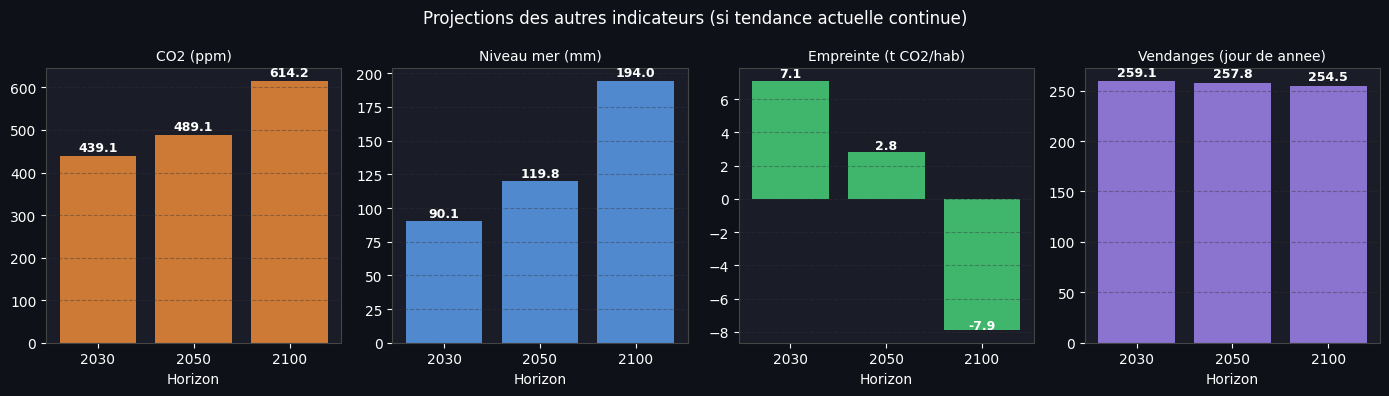

In [9]:
resultats_proj = {}
for annee_cible in [2030, 2050, 2100]:
    row = {}
    for nom, label in [
        ('co2',               'CO2 (ppm)'),
        ('niveau_mer',        'Niveau mer (mm)'),
        ('empreinte_carbone', 'Empreinte (t CO2/hab)'),
        ('vendanges',         'Vendanges (jour de annee)'),
    ]:
        path = 'data/resultats/forecast_' + nom + '.csv'
        if os.path.exists(path):
            fc  = pd.read_csv(path)
            val = fc[fc['annee'] == annee_cible]['yhat']
            row[label] = round(float(val.values[0]), 1) if not val.empty else 'N/A'
    resultats_proj[annee_cible] = row

df_proj = pd.DataFrame(resultats_proj).T
df_proj.index.name = 'Horizon'
if not df_proj.empty:
    fig, axes = plt.subplots(1, len(df_proj.columns), figsize=(14, 4))
    couleurs_ind = ['#fb923c', '#60a5fa', '#4ade80', '#a78bfa']
    for ax, (col, coul) in zip(axes, zip(df_proj.columns, couleurs_ind)):
        vals = df_proj[col].values
        ax.bar(df_proj.index.astype(str), vals, color=coul, alpha=0.8, edgecolor='none')
        for i, v in enumerate(vals):
            ax.text(i, float(v) + float(v)*0.01, str(v),
                    ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')
        ax.set_title(col, fontsize=10)
        ax.set_xlabel('Horizon'); ax.grid(True, axis='y', alpha=0.4)
    fig.suptitle('Projections des autres indicateurs (si tendance actuelle continue)', fontsize=12)
    plt.tight_layout()
    plt.savefig('data/resultats/fig_projections_indicateurs.png', dpi=150, bbox_inches='tight')
    plt.show()

Au-delà de la température, les projections sur les autres indicateurs confirment l'ampleur du défi. Le CO₂ continue de monter si aucun changement majeur n'intervient. Le niveau de la mer s'accélère. Et les vendanges, qui arrivent déjà deux semaines plus tôt qu'en 1950, continueront à avancer — avec des conséquences croissantes sur la viticulture française.

---
## 8. Ce qu'on peut faire concrètement

Les projections ne servent à rien si elles ne débouchent pas sur des actions. Cette section traduit les signaux identifiés dans les données en recommandations concrètes, organisées par type de risque. Ces recommandations sont alignées avec le Plan National d'Adaptation au Changement Climatique (PNACC 3, 2024) et les axes prioritaires de l'Earth Action Report 2025.

---

### Face au risque de canicule, qui s'intensifie dès 2030

Les données montrent que les jours de forte chaleur augmentent dans tous les scénarios, y compris le plus optimiste. Les villes denses, sans végétation et sans accès à des espaces frais, seront les plus vulnérables.

Pour les citoyens : rester hydraté, adapter les horaires d'activité physique, et surtout veiller sur les personnes âgées et les personnes fragiles du voisinage. Pour les collectivités : végétaliser les espaces publics, créer des îlots de fraîcheur, et mettre en place des dispositifs de rafraîchissement (fontaines, brumisateurs, zones d'ombre).

*Alignement PNACC 3 : axe Santé — Earth Action Report 2025 : axe Adaptation*

---

### Face au risque de sécheresse, déjà visible dans le Sud

La baisse des précipitations estivales et l'augmentation de l'évapotranspiration vont intensifier les épisodes de sécheresse, en particulier dans le bassin méditerranéen et le Sud-Ouest.

Pour les particuliers : récupérer l'eau de pluie, remplacer les plantes à fort besoin en eau par des espèces résistantes à la sécheresse, réduire les arrosages. Pour les agriculteurs et les gestionnaires de territoires : réviser les plans d'irrigation en s'appuyant sur les projections DRIAS, qui donnent des données régionalisées.

*Alignement PNACC 3 : axe Eau — Earth Action Report 2025 : axe Résilience*

---

### Face au risque de feux de forêt

Les données montrent une augmentation des surfaces brûlées en France, en particulier dans le Sud-Est. Ce risque va s'intensifier avec la hausse des températures et la sécheresse estivale.

Les actions prioritaires sont le débroussaillage dans les zones à risque (obligatoire dans un périmètre de 50 mètres autour des habitations en zone forestière), l'adaptation des projets de construction en interface forêt-ville, et la mise à jour régulière des plans communaux de sauvegarde.

*Alignement PNACC 3 : axe Forêts — Earth Action Report 2025 : axe Mobilisation citoyenne*

---

### Pour réduire l'empreinte carbone individuelle

On est à 9 tonnes de CO₂ par personne et par an. L'objectif pour atteindre la neutralité carbone en 2050 (SNBC) est de 2 tonnes. Diviser par 4 en 25 ans, c'est faisable, mais ça demande des changements dans les trois postes qui pèsent le plus lourd.

Les transports représentent environ 30% de l'empreinte individuelle en France. Privilégier le vélo, les transports en commun et le covoiturage pour les trajets quotidiens est le levier individuel le plus efficace. L'alimentation est le deuxième poste : réduire la consommation de viande rouge divise à peu près par deux l'empreinte alimentaire. Enfin, la rénovation énergétique du logement (isolation, changement de système de chauffage) est le troisième levier majeur, souvent rentable à moyen terme grâce aux économies d'énergie.

*Alignement SNBC 2050 — PNACC 3 : axe Énergie — Accord de Paris : objectif +1.5°C*

---

### Récapitulatif des engagements et où on en est

| Engagement | Objectif | Situation actuelle | Ce qui reste à faire |
|---|---|---|---|
| Accord de Paris | +1.5°C max mondial | +2.6°C déjà atteint en France | Réduire les émissions d'urgence |
| SNBC | Neutralité carbone 2050 | 9 t CO₂/hab (objectif : 2 t) | Diviser par 4 en 25 ans |
| PNACC 3 | Adapter la France à +4°C | Plan lancé en 2024 | Mise en oeuvre sur 2024-2030 |
| Earth Action Report 2025 | Changement systémique | 4 axes prioritaires | Adaptation, énergie, résilience, mobilisation |

---

*Ce rapport a été produit dans le cadre du Hackathon #26 — Sup de Vinci, 16-17 mars 2026.
Les données utilisées sont issues de sources officielles publiques : Météo France, NOAA, CITEPA, PSMSL, INSEE/SDES, EM-DAT.
Le code source complet est disponible dans les fichiers pipeline.py, modele_prophet.py, modele_comparaison.py et app.py.*